Reading initial snapshot at z=63...
Computing PM Mesh local overdensity (delta)...

Using CIC mass assignment scheme
Time taken = 0.052 seconds

Reading final snapshot at z=0...
Rendering 3D comparison plot...


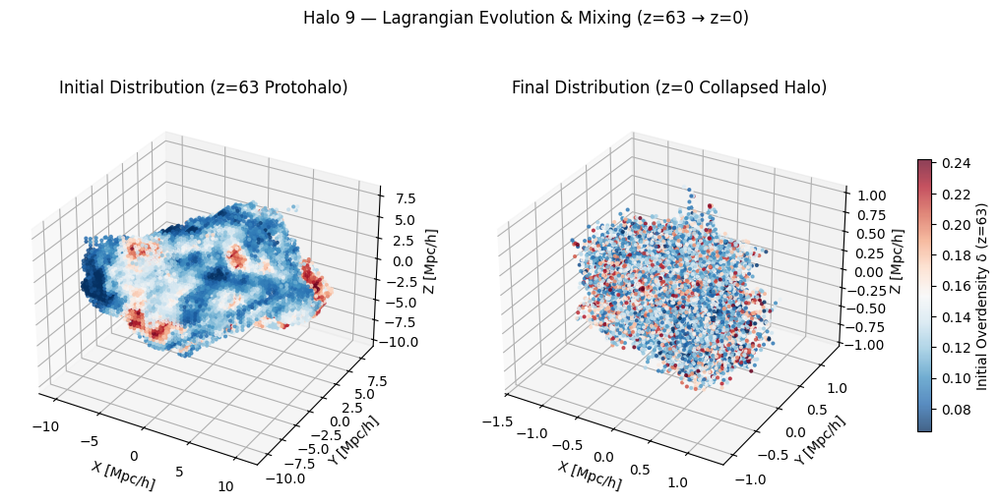

[0.12865505 0.16164371 0.08566444 ... 0.10318109 0.081317   0.10443767]


In [15]:
import numpy as np
import readgadget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3d projection registration)
from scipy.interpolate import RegularGridInterpolator
import MAS_library as MASL

# =====================================================================
# 1. FILE PATHS & SETUP
# =====================================================================
snap_init  = "./output/snap_000.hdf5"        # Initial snapshot (z=63)
snap_final = "./output/snap_192.hdf5"        # Final snapshot (z=0)
halo_npz_path = "all_ParticleIDs_halo_mapped.npz"
boxsize = readgadget.header(snap_final).boxsize

ptype = [1]  # Dark matter particles

halo_data = np.load(halo_npz_path)
halo_particle_ids = halo_data["halo_2"]

# =====================================================================
# 2. EXTRACT & CENTER INITIAL POSITIONS (z=63) + PM OVERDENSITY
# =====================================================================
print("Reading initial snapshot at z=63...")
init_positions = readgadget.read_block(snap_init, "POS ", ptype)
all_init_ids   = readgadget.read_block(snap_init, "ID  ", ptype)

init_id_map = {pid: idx for idx, pid in enumerate(all_init_ids)}
halo_init_indices  = [init_id_map[pid] for pid in halo_particle_ids]
halo_init_positions = init_positions[halo_init_indices]

init_center_x = np.median(halo_init_positions[:, 0])
init_center_y = np.median(halo_init_positions[:, 1])
init_center_z = np.median(halo_init_positions[:, 2])

x_init_3d = halo_init_positions[:, 0] - init_center_x
y_init_3d = halo_init_positions[:, 1] - init_center_y
z_init_3d = halo_init_positions[:, 2] - init_center_z

print("Computing PM Mesh local overdensity (delta)...")
grid = 256
delta = np.zeros((grid, grid, grid), dtype=np.float32)
MASL.MA(init_positions, delta, boxsize, MAS='CIC', verbose=True)

grid_edges = np.linspace(0.0, boxsize, grid + 1)
edges = [grid_edges, grid_edges, grid_edges]

x_centers = 0.5 * (edges[0][:-1] + edges[0][1:])
y_centers = 0.5 * (edges[1][:-1] + edges[1][1:])
z_centers = 0.5 * (edges[2][:-1] + edges[2][1:])

rgi = RegularGridInterpolator(
    (x_centers, y_centers, z_centers),
    delta,
    bounds_error=False,
    fill_value=0.0
)
overdensity_delta = rgi(halo_init_positions)

# =====================================================================
# 3. TRACK & CENTER 3D POSITIONS AT FINAL SNAPSHOT (z=0)
# =====================================================================
print("Reading final snapshot at z=0...")
all_final_positions = readgadget.read_block(snap_final, "POS ", ptype)
all_final_ids        = readgadget.read_block(snap_final, "ID  ", ptype)

final_id_map = {pid: idx for idx, pid in enumerate(all_final_ids)}
halo_final_indices  = [final_id_map[pid] for pid in halo_particle_ids]
halo_final_positions = all_final_positions[halo_final_indices]

center_x = np.median(halo_final_positions[:, 0])
center_y = np.median(halo_final_positions[:, 1])
center_z = np.median(halo_final_positions[:, 2])

x_final_3d = halo_final_positions[:, 0] - center_x
y_final_3d = halo_final_positions[:, 1] - center_y
z_final_3d = halo_final_positions[:, 2] - center_z

# =====================================================================
# 4. RENDER SIDE-BY-SIDE 3D COMPARISON PLOT (z=63 vs z=0) — matplotlib
# =====================================================================
print("Rendering 3D comparison plot...")

vmin = np.percentile(overdensity_delta, 2)
vmax = np.percentile(overdensity_delta, 98)

fig = plt.figure(figsize=(14, 6))

# --- Panel 1: Initial distribution at z=63 ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(
    x_init_3d, y_init_3d, z_init_3d,
    c=overdensity_delta, cmap='RdBu_r',
    vmin=vmin, vmax=vmax,
    s=4, alpha=0.75
)
ax1.set_title("Initial Distribution (z=63 Protohalo)")
ax1.set_xlabel("X [Mpc/h]")
ax1.set_ylabel("Y [Mpc/h]")
ax1.set_zlabel("Z [Mpc/h]")

# --- Panel 2: Final distribution at z=0 (same colour-per-particle) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(
    x_final_3d, y_final_3d, z_final_3d,
    c=overdensity_delta, cmap='RdBu_r',
    vmin=vmin, vmax=vmax,
    s=4, alpha=0.75
)
ax2.set_title("Final Distribution (z=0 Collapsed Halo)")
ax2.set_xlabel("X [Mpc/h]")
ax2.set_ylabel("Y [Mpc/h]")
ax2.set_zlabel("Z [Mpc/h]")

# shared colourbar, matching the single colourbar in the Plotly version
cbar = fig.colorbar(sc2, ax=[ax1, ax2], shrink=0.6, pad=0.05)
cbar.set_label("Initial Overdensity δ (z=63)")

fig.suptitle("Halo 9 — Lagrangian Evolution & Mixing (z=63 → z=0)")
plt.show()


Reading initial snapshot at z=63...
Computing PM Mesh local overdensity (delta)...

Using CIC mass assignment scheme
Time taken = 0.046 seconds

Reading final snapshot at z=0...
Rendering 3D comparison plot...


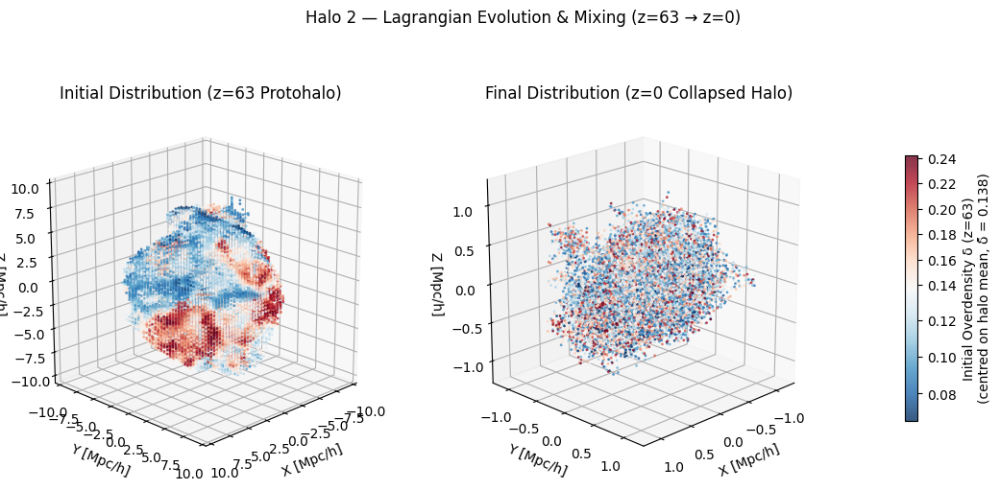

In [3]:
#clarified with claude what the "end goal" was
import numpy as np
import readgadget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import TwoSlopeNorm
from scipy.interpolate import RegularGridInterpolator
import MAS_library as MASL

# =====================================================================
# 1. FILE PATHS & SETUP
# =====================================================================
snap_init  = "./output/snap_000.hdf5"        # Initial snapshot (z=63)
snap_final = "./output/snap_192.hdf5"        # Final snapshot (z=0)
halo_npz_path = "all_ParticleIDs_halo_mapped.npz"
boxsize = readgadget.header(snap_final).boxsize
ptype = [1]  # Dark matter particles

halo_data = np.load(halo_npz_path)
halo_particle_ids = halo_data["halo_2"]

def match_ids(all_ids, target_ids):
    """Vectorized ID -> index lookup (avoids building a Python dict over
    the full snapshot, which is the real bottleneck at large N)."""
    order      = np.argsort(all_ids)
    ids_sorted = all_ids[order]
    loc        = np.searchsorted(ids_sorted, target_ids)
    idx        = order[loc]
    assert np.all(all_ids[idx] == target_ids), "Some target IDs not found in snapshot!"
    return idx

# =====================================================================
# 2. INITIAL SNAPSHOT (z=63): positions + PM overdensity at each particle
# =====================================================================
print("Reading initial snapshot at z=63...")
init_positions = readgadget.read_block(snap_init, "POS ", ptype)
all_init_ids   = readgadget.read_block(snap_init, "ID  ", ptype)

halo_init_indices   = match_ids(all_init_ids, halo_particle_ids)
halo_init_positions = init_positions[halo_init_indices]

init_center = np.median(halo_init_positions, axis=0)
x_init_3d, y_init_3d, z_init_3d = (halo_init_positions - init_center).T

print("Computing PM Mesh local overdensity (delta)...")
grid = 256
delta = np.zeros((grid, grid, grid), dtype=np.float32)
MASL.MA(init_positions, delta, boxsize, MAS='CIC', verbose=True)

grid_edges = np.linspace(0.0, boxsize, grid + 1)
centers    = 0.5 * (grid_edges[:-1] + grid_edges[1:])

rgi = RegularGridInterpolator(
    (centers, centers, centers), delta, bounds_error=False, fill_value=0.0
)
overdensity_delta = rgi(halo_init_positions)

# =====================================================================
# 3. FINAL SNAPSHOT (z=0): track the SAME particles by ID
# =====================================================================
print("Reading final snapshot at z=0...")
all_final_positions = readgadget.read_block(snap_final, "POS ", ptype)
all_final_ids        = readgadget.read_block(snap_final, "ID  ", ptype)

halo_final_indices   = match_ids(all_final_ids, halo_particle_ids)
halo_final_positions = all_final_positions[halo_final_indices]

final_center = np.median(halo_final_positions, axis=0)
x_final_3d, y_final_3d, z_final_3d = (halo_final_positions - final_center).T

# =====================================================================
# 4. PLOT: side-by-side 3D comparison, same colour-per-particle, same view
# =====================================================================
print("Rendering 3D comparison plot...")

#centred at mean overdensity in the protohalo
vmin = np.percentile(overdensity_delta, 2)
vmax = np.percentile(overdensity_delta, 98)
vcenter = np.mean(overdensity_delta)   # centre on this halo's own average, not physical delta=0

# Guard: TwoSlopeNorm still requires vmin < vcenter < vmax
if vmin >= vcenter:
    vmin = min(overdensity_delta.min(), vcenter - 1e-3)
if vmax <= vcenter:
    vmax = max(overdensity_delta.max(), vcenter + 1e-3)

norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

# Draw high-|delta| particles LAST so they sit visually on top -
# matters in matplotlib 3D since it doesn't true-depth-blend like Plotly/WebGL
draw_order = np.argsort(np.abs(overdensity_delta - np.median(overdensity_delta)))

def plot_panel(ax, x, y, z, title):
    sc = ax.scatter(
        x[draw_order], y[draw_order], z[draw_order],
        c=overdensity_delta[draw_order], cmap='RdBu_r', norm=norm,
        s=4, alpha=0.8, linewidths=0, rasterized=True   # rasterized -> lighter file/render
    )
    ax.set_title(title)
    ax.set_xlabel("X [Mpc/h]")
    ax.set_ylabel("Y [Mpc/h]")
    ax.set_zlabel("Z [Mpc/h]")

    # equal aspect box, scaled to THIS panel's own data span
    span = np.ptp(np.stack([x, y, z]), axis=1).max() / 2
    cx, cy, cz = x.mean(), y.mean(), z.mean()
    ax.set_xlim(cx - span, cx + span)
    ax.set_ylim(cy - span, cy + span)
    ax.set_zlim(cz - span, cz + span)
    ax.set_box_aspect([1, 1, 1])

    # same viewing angle on both panels -> a fair visual comparison
    ax.view_init(elev=20, azim=45)
    return sc

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

plot_panel(ax1, x_init_3d, y_init_3d, z_init_3d,
           "Initial Distribution (z=63 Protohalo)")
sc2 = plot_panel(ax2, x_final_3d, y_final_3d, z_final_3d,
                  "Final Distribution (z=0 Collapsed Halo)")

cbar = fig.colorbar(sc2, ax=[ax1, ax2], shrink=0.6, pad=0.08)
cbar.set_label(f"Initial Overdensity δ (z=63)\n(centred on halo mean, δ̄ = {vcenter:.3f})")

fig.suptitle("Halo 2 — Lagrangian Evolution & Mixing (z=63 → z=0)")
plt.show()

In [4]:
#above but with plotly

import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ------------------------------------------------------------------
# Build a diverging colorscale whose WHITE midpoint sits exactly at
# vcenter, even when vmin/vmax aren't symmetric around it - this
# replicates matplotlib's TwoSlopeNorm behaviour, which Plotly's
# built-in cmin/cmax linear scaling does not do on its own.
# ------------------------------------------------------------------
def two_slope_colorscale(vmin, vcenter, vmax, cmap_name='RdBu_r', n=11):
    cmap = cm.get_cmap(cmap_name)
    mid_pos = (vcenter - vmin) / (vmax - vmin)

    stops = []
    for frac in np.linspace(0.0, 0.5, n):
        pos = frac / 0.5 * mid_pos
        stops.append([pos, mcolors.to_hex(cmap(frac))])
    for frac in np.linspace(0.5, 1.0, n)[1:]:
        pos = mid_pos + (frac - 0.5) / 0.5 * (1 - mid_pos)
        stops.append([pos, mcolors.to_hex(cmap(frac))])
    return stops

# ------------------------------------------------------------------
# Centre on the protohalo's OWN mean overdensity, not physical delta=0
# ------------------------------------------------------------------
vmin    = np.percentile(overdensity_delta, 2)
vmax    = np.percentile(overdensity_delta, 98)
vcenter = np.mean(overdensity_delta)

if vmin >= vcenter:
    vmin = min(overdensity_delta.min(), vcenter - 1e-3)
if vmax <= vcenter:
    vmax = max(overdensity_delta.max(), vcenter + 1e-3)

colorscale = two_slope_colorscale(vmin, vcenter, vmax)

# ------------------------------------------------------------------
# Side-by-side 3D comparison, same colour-per-particle, mean-centred
# ------------------------------------------------------------------
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("Initial Distribution (z=63 Protohalo)",
                     "Final Distribution (z=0 Collapsed Halo)")
)

fig.add_trace(
    go.Scatter3d(
        x=x_init_3d, y=y_init_3d, z=z_init_3d,
        mode="markers",
        marker=dict(
            size=2,
            color=overdensity_delta,
            colorscale=colorscale,
            cmin=vmin, cmax=vmax,
            showscale=False,
            opacity=0.75
        ),
        hovertext=[
            f"PID: {pid}<br>δ (z=63): {d:.3f}"
            for pid, d in zip(halo_particle_ids, overdensity_delta)
        ],
        hoverinfo="text"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter3d(
        x=x_final_3d, y=y_final_3d, z=z_final_3d,
        mode="markers",
        marker=dict(
            size=2,
            color=overdensity_delta,
            colorscale=colorscale,
            cmin=vmin, cmax=vmax,
            colorbar=dict(
                title=dict(text=f"δ (z=63), centred on halo mean = {vcenter:.3f}", side="right"),
                thickness=15
            ),
            showscale=True,
            opacity=0.75
        ),
        hovertext=[
            f"PID: {pid}<br>δ (z=63): {d:.3f}"
            for pid, d in zip(halo_particle_ids, overdensity_delta)
        ],
        hoverinfo="text"
    ),
    row=1, col=2
)

fig.update_layout(
    title="Halo 2 — Lagrangian Evolution & Mixing (z=63 → z=0), centred on protohalo mean δ",
    scene=dict(xaxis_title="X [Mpc/h]", yaxis_title="Y [Mpc/h]", zaxis_title="Z [Mpc/h]", aspectmode="data"),
    scene2=dict(xaxis_title="X [Mpc/h]", yaxis_title="Y [Mpc/h]", zaxis_title="Z [Mpc/h]", aspectmode="data"),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

/var/folders/9z/6j3ff9390ngcmyd4dv2mxhvr0000gn/T/ipykernel_83463/3387611612.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


In [5]:
# DOESN'T USE DIVERGING COLORMAP
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

vmin = np.min(overdensity_delta)
vmax = np.max(overdensity_delta)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("Initial Distribution (z=63 Protohalo)",
                     "Final Distribution (z=0 Collapsed Halo)")
)

fig.add_trace(
    go.Scatter3d(
        x=x_init_3d, y=y_init_3d, z=z_init_3d,
        mode="markers",
        marker=dict(
            size=2,
            color=overdensity_delta,
            colorscale="Plasma",
            cmin=vmin, cmax=vmax,
            showscale=False,
            opacity=0.75
        ),
        hovertext=[
            f"PID: {pid}<br>δ (z=63): {d:.3f}"
            for pid, d in zip(halo_particle_ids, overdensity_delta)
        ],
        hoverinfo="text"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter3d(
        x=x_final_3d, y=y_final_3d, z=z_final_3d,
        mode="markers",
        marker=dict(
            size=2,
            color=overdensity_delta,
            colorscale="Plasma",
            cmin=vmin, cmax=vmax,
            colorbar=dict(
                title=dict(text="Initial Overdensity δ (z=63)", side="right"),
                thickness=15
            ),
            showscale=True,
            opacity=0.75
        ),
        hovertext=[
            f"PID: {pid}<br>δ (z=63): {d:.3f}"
            for pid, d in zip(halo_particle_ids, overdensity_delta)
        ],
        hoverinfo="text"
    ),
    row=1, col=2
)

fig.update_layout(
    title="Halo 2 — Lagrangian Evolution & Mixing (z=63 → z=0)",
    scene=dict(xaxis_title="X [Mpc/h]", yaxis_title="Y [Mpc/h]", zaxis_title="Z [Mpc/h]", aspectmode="data"),
    scene2=dict(xaxis_title="X [Mpc/h]", yaxis_title="Y [Mpc/h]", zaxis_title="Z [Mpc/h]", aspectmode="data"),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

No. of particles in the 99.9th percentile = 32
[0.05277424 0.25207849 0.26008401 0.27048237 0.27766984 0.28375476
 0.2904443  0.29308042 0.30245053]


Skewness = 0.653


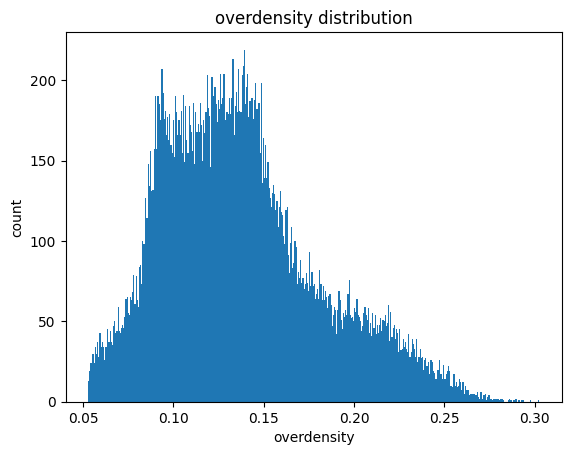

In [34]:
#USING PERCENTILES
#PLASMA COLORMAP
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from scipy.stats import skew

higher = 99.9
lower = 0
vmin, vmax = np.percentile(overdensity_delta, [lower, higher])  #high percentile cut off means more particles coloured with the intermediate values

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("z=63 (initial overdensity distribution)",
                     "z=0 (final particle distribution painted with initial δ)")
)

fig.add_trace(
    go.Scatter3d(
        x=x_init_3d, y=y_init_3d, z=z_init_3d,
        mode="markers",
        marker=dict(                        #this does a data clipping similar to np.clip while rendering
            size=2,
            color=overdensity_delta,
            colorscale="Plasma",
            cmin=vmin, cmax=vmax,
            showscale=False,
            opacity=0.75
        ),
        hovertext=[
            f"PID: {pid}<br>δ (z=63): {d:.3f}"
            for pid, d in zip(halo_particle_ids, overdensity_delta)
        ],
        hoverinfo="text"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter3d(
        x=x_final_3d, y=y_final_3d, z=z_final_3d,
        mode="markers",
        marker=dict(
            size=2,
            color=overdensity_delta,
            colorscale="Plasma",
            cmin=vmin, cmax=vmax,
            colorbar=dict(
                title=dict(text="Initial Overdensity δ (z=63)", side="right"),
                thickness=15
            ),
            showscale=True,
            opacity=0.75
        ),
        hovertext=[
            f"PID: {pid}<br>δ (z=63): {d:.3f}"
            for pid, d in zip(halo_particle_ids, overdensity_delta)
        ],
        hoverinfo="text"
    ),
    row=1, col=2
)

fig.update_layout(
    title="Spatial Evolution of Initial Overdensity (clipped)",
    scene=dict(xaxis_title="X [Mpc/h]", yaxis_title="Y [Mpc/h]", zaxis_title="Z [Mpc/h]", aspectmode="data"),
    scene2=dict(xaxis_title="X [Mpc/h]", yaxis_title="Y [Mpc/h]", zaxis_title="Z [Mpc/h]", aspectmode="data"),
    margin=dict(l=0, r=0, b=0, t=50)
)

particles_in_higher_percentile = np.sum(overdensity_delta>=vmax)
print(f"No. of particles in the {higher}th percentile = {particles_in_higher_percentile}")
print(np.percentile(overdensity_delta,[0,99,99.5,99.8,99.9,99.95,99.98,99.99,100]))
fig.show()

plt.hist(overdensity_delta, bins=400)
plt.xlabel("overdensity")
plt.ylabel("count")
plt.title("overdensity distribution")
plt.show

print(f"Skewness = {skew(overdensity_delta):.3f}")

In [29]:
print(len(halo_particle_ids))

31295


In [ ]:
print(np.ptp(overdensity_delta))
print(np.max(overdensity_delta)-np.min(overdensity_delta))

In [ ]:
import os
import glob
import numpy as np
import readgadget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import Normalize
from scipy.interpolate import RegularGridInterpolator
import MAS_library as MASL
import imageio.v2 as imageio

# =====================================================================
# CONFIG
# =====================================================================
OUTPUT_DIR   = "./output"
ref_snap     = 0                       # snapshot that DEFINES each particle's origin colour
n_snapshots  = 193                     # snap_000 ... snap_192
ptype        = [1]                     # dark matter
grid         = 256
halo_npz_path = "all_ParticleIDs_halo_mapped.npz"

frame_dir  = "overdensity_frames_claude"
video_path = "overdensity_evolution.mp4"
fps        = 15

os.makedirs(frame_dir, exist_ok=True)

def snap_path(n):
    return f"{OUTPUT_DIR}/snap_{n:03d}.hdf5"

def match_ids(all_ids, target_ids):
    """Vectorized ID -> index lookup (fast for full-snapshot particle counts)."""
    order      = np.argsort(all_ids)
    ids_sorted = all_ids[order]
    loc        = np.searchsorted(ids_sorted, target_ids)
    idx        = order[loc]
    assert np.all(all_ids[idx] == target_ids), "Some target IDs not found in snapshot!"
    return idx

# =====================================================================
# STEP 1: reference snapshot -> fixed per-particle "origin" overdensity
# =====================================================================
print(f"Reading reference snapshot {ref_snap} (defines fixed particle colours)...")
boxsize       = readgadget.header(snap_path(ref_snap)).boxsize
ref_positions = readgadget.read_block(snap_path(ref_snap), "POS ", ptype)
ref_ids       = readgadget.read_block(snap_path(ref_snap), "ID  ", ptype)

halo_data         = np.load(halo_npz_path)
halo_particle_ids = halo_data["halo_2"]

halo_ref_indices   = match_ids(ref_ids, halo_particle_ids)
halo_ref_positions = ref_positions[halo_ref_indices]

print("Computing PM Mesh local overdensity (delta) at reference snapshot...")
delta = np.zeros((grid, grid, grid), dtype=np.float32)
MASL.MA(ref_positions, delta, boxsize, MAS='CIC', verbose=True)

grid_edges = np.linspace(0.0, boxsize, grid + 1)
centers    = 0.5 * (grid_edges[:-1] + grid_edges[1:])
rgi = RegularGridInterpolator(
    (centers, centers, centers), delta, bounds_error=False, fill_value=0.0
)
overdensity_delta = rgi(halo_ref_positions)   # FIXED colour value per particle, from here on

# Fixed colour scale for every frame - must NOT change snapshot to snapshot,
# or the colour meaning would drift across the video
vmin, vmax = np.percentile(overdensity_delta, [1, 99])
norm = Normalize(vmin=vmin, vmax=vmax)
draw_order = np.argsort(overdensity_delta)   # densest particles drawn last (on top) every frame

# Fixed spatial box size for every frame, so the animation doesn't rescale
# jarringly between frames - use the initial protohalo spread
span = np.ptp(halo_ref_positions, axis=0).max() / 2

# =====================================================================
# STEP 2: loop over every snapshot, render + save each frame as a PNG
# =====================================================================
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(1, 1, 1, projection='3d')

for snap in range(n_snapshots):
    print(f"Rendering snapshot {snap+1}/{n_snapshots}...", end='\r')

    positions = readgadget.read_block(snap_path(snap), "POS ", ptype)
    ids       = readgadget.read_block(snap_path(snap), "ID  ", ptype)
    redshift = readgadget.header(snap_path(snap)).redshift

    halo_indices   = match_ids(ids, halo_particle_ids)
    halo_positions = positions[halo_indices]

    center = np.median(halo_positions, axis=0)
    x, y, z = (halo_positions - center).T

    ax.clear()
    ax.scatter(
        x[draw_order], y[draw_order], z[draw_order],
        c=overdensity_delta[draw_order], cmap='plasma', norm=norm,
        s=4, alpha=0.85, linewidths=0
    )
    ax.set_title(f"Halo 2 — Z = {redshift:4.2f}")
    ax.set_xlabel("X [Mpc/h]")
    ax.set_ylabel("Y [Mpc/h]")
    ax.set_zlabel("Z [Mpc/h]")
    ax.set_xlim(-span, span)
    ax.set_ylim(-span, span)
    ax.set_zlim(-span, span)
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=20, azim=45)

    frame_path = os.path.join(frame_dir, f"frame_{snap:03d}.png")
    fig.savefig(frame_path, dpi=150)

plt.close(fig)
print(f"\nAll {n_snapshots} frames saved to '{frame_dir}/'.")

# =====================================================================
# STEP 3: stitch the saved frames into a video with imageio
# =====================================================================
print("Assembling video from saved frames...")
frame_files = sorted(glob.glob(os.path.join(frame_dir, "frame_*.png")))
assert len(frame_files) == n_snapshots, \
    f"Expected {n_snapshots} frames, found {len(frame_files)} - check for missing snapshots."

with imageio.get_writer(video_path, fps=fps) as writer:
    for f in frame_files:
        writer.append_data(imageio.imread(f))

print(f"Done. Video saved to '{video_path}'.")
